In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

# Phase 5 — Blocking, hybrid matching and clustering

Computed by `python -m src.match` (benchmarks), `python -m src.match bb_sample` and `bb_eval` (BigBasket).

## 1. Blocking

In [2]:
import json; meta = json.load(open(ROOT/'reports'/'phase5_meta.json')); pd.DataFrame({k: meta[k]['blocking'] for k in ['abt_buy','amazon_google']})

,abt_buy,amazon_google
candidates,7.607500e+04,1.029320e+05
all_pairs,1.180452e+06,4.397038e+06
reduction_ratio,9.356000e-01,9.766000e-01
pair_completeness,9.990000e-01,9.910000e-01
seconds,3.000000e-01,2.000000e-01


## 2. Pair matching (test splits; thresholds/weights tuned on validation)

In [3]:
pm = pd.read_csv(ROOT/'reports'/'phase5_pair_matching.csv'); pm

,dataset,config,precision,recall,f1,val_f1,w_sbert,brand_penalty,model_penalty,threshold
0,abt_buy,char TF-IDF only,0.542,0.516,0.529,0.533,0.00,0.0,0.0,0.671
1,abt_buy,SBERT only,0.436,0.475,0.455,0.453,1.00,0.0,0.0,0.838
2,abt_buy,hybrid (no rules),0.542,0.516,0.529,0.533,0.00,0.0,0.0,0.671
3,abt_buy,hybrid + rules (no model-number rule),0.544,0.516,0.530,0.533,0.00,0.0,0.0,0.671
4,abt_buy,hybrid + all rules,0.737,0.769,0.753,0.737,0.75,0.0,0.2,0.685
5,amazon_google,char TF-IDF only,0.447,0.595,0.511,0.511,0.00,0.0,0.0,0.690
6,amazon_google,SBERT only,0.388,0.445,0.415,0.410,1.00,0.0,0.0,0.777
7,amazon_google,hybrid (no rules),0.447,0.595,0.511,0.511,0.00,0.0,0.0,0.690
8,amazon_google,hybrid + rules (no model-number rule),0.446,0.594,0.510,0.511,0.00,0.0,0.0,0.690
9,amazon_google,hybrid + all rules,0.448,0.592,0.510,0.516,0.00,0.0,0.2,0.690


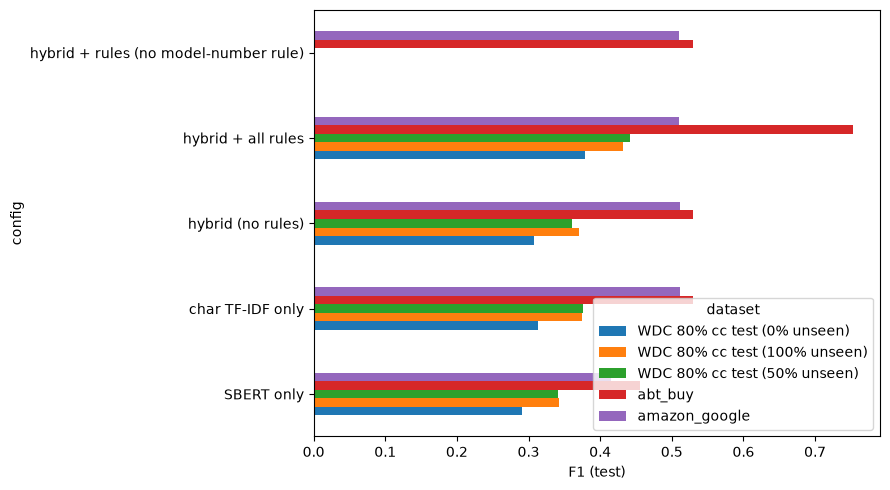

In [4]:
ax = pm.pivot(index='config', columns='dataset', values='f1').plot.barh(figsize=(9,5)); ax.set_xlabel('F1 (test)')
plt.tight_layout(); plt.savefig(FIG/'phase5_pair_f1.png', dpi=120)

## 3. Clustering on WDC multi-class test (1,000 offers, 500 products)

In [5]:
pd.read_csv(ROOT/'reports'/'phase5_clustering.csv')

,method,threshold,ARI,NMI,V-measure,clusters
0,connected components,0.700,0.192,0.932,0.932,749
1,agglomerative (average),0.525,0.296,0.924,0.924,530
2,HDBSCAN (SBERT vectors),NaN,0.174,0.887,0.887,374
3,baseline: every offer alone,NaN,0.000,0.947,0.947,1000


![UMAP](../reports/figures/phase5_umap_wdc.png)

## 4. BigBasket: 500 labelled pairs (provisional labels) and the cluster_id column

In [6]:
pd.read_csv(ROOT/'reports'/'phase5_bigbasket_pairs.csv')

,config,precision,recall,f1,val_f1,w_sbert,threshold,test_pairs,test_positives
0,char TF-IDF only,0.408,0.879,0.558,0.532,0.00,1.0,251,33
1,SBERT only,0.450,0.818,0.581,0.549,1.00,1.0,251,33
2,hybrid (no rules),0.450,0.818,0.581,0.549,0.25,1.0,251,33
3,hybrid + qty/pack/brand rules,0.450,0.818,0.581,0.549,0.25,1.0,251,33
4,hybrid + rules + MRP rule,0.935,0.879,0.906,0.962,0.00,1.0,251,33


In [7]:
json.load(open(ROOT/'reports'/'phase5_bigbasket_clusters.json'))

{'config_used': 'hybrid + rules + MRP rule',
 'records': 27555,
 'clusters': 26487,
 'multi_member_clusters': 996,
 'records_in_multi': 2064,
 'largest_cluster': 12}

In [8]:
bb = pd.read_parquet(ROOT/'data'/'processed'/'bigbasket_clusters.parquet')
sizes = bb['cluster_id'].value_counts()
ex = bb[bb['cluster_id'].isin(sizes[sizes > 2].index[:8])].sort_values('cluster_id')
ex[['cluster_id', 'brand', 'product_name', 'mrp', 'sale_price' if 'sale_price' in bb else 'price']]

,cluster_id,brand,product_name,mrp,price
37,37,Engage,Bodylicious Deodorant Spray - Mate (For Men),195.0,136.50
7416,37,Engage,Bodylicious Deodorant Spray - Mate (For Men),195.0,136.50
26183,37,Engage,Bodylicious Deodorant Spray - Mate (For Men),195.0,136.50
21003,37,Engage,Bodylicious Deodorant Spray - Mate (For Men),195.0,136.50
7026,1177,Park avenue,Fragrance Body Spray - Tranquil,199.0,179.10
22387,1177,Park avenue,Fragrance Body Spray - Tranquil,199.0,189.05
2322,1177,Park avenue,Fragrance Body Spray - Tranquil,199.0,189.05
1181,1177,Park avenue,Fragrance Body Spray - Tranquil,199.0,179.10
12442,1955,Loreal Paris,Excellence Creme Hair Color,620.0,527.00
9003,1955,Loreal Paris,Excellence Creme Hair Color,620.0,527.00


## 5. Abt-Buy errors of the best configuration

In [9]:
import numpy as np
from src.match import hybrid_score
from src.embed import load_benchmark
c = pd.read_parquet(ROOT/'data'/'processed'/'phase5_abt_buy_candidates.parquet')
p = meta['abt_buy']['params']['hybrid + all rules']
c['score'] = hybrid_score(c, p['w'], p['brand_penalty'], p['model_penalty'])
t = c[~c['is_val']]
left, right, _ = load_benchmark('abt_buy')
ln, rn = dict(zip(left['id'], left['raw'])), dict(zip(right['id'], right['raw']))
fp = t[(t['score'] >= p['threshold']) & ~t['label']].nlargest(5, 'score')
fn = t[(t['score'] < p['threshold']) & t['label']].nsmallest(5, 'score')
pd.concat([fp.assign(error='FP'), fn.assign(error='FN')]).assign(abt=lambda d: d['left_id'].map(ln), buy=lambda d: d['right_id'].map(rn))[['error','score','sbert','char','code_conflict','abt','buy']]

,error,score,sbert,char,code_conflict,abt,buy
35410,FP,0.952578,0.947551,0.967659,False,Sony DVP-FX820 Black 8' Portable DVD Player - DVPFX820,Sony DVP-FX820/P Portable DVD Player - DVPFX820/P
35390,FP,0.951071,0.952170,0.947775,False,Sony DVP-FX820 Black 8' Portable DVD Player - DVPFX820,Sony DVP-FX820/L Portable DVD Player - DVPFX820/L
35391,FP,0.950126,0.946502,0.960999,False,Sony DVP-FX820 Black 8' Portable DVD Player - DVPFX820,Sony DVP-FX820/R Portable DVD Player - DVPFX820/R
35555,FP,0.932544,0.932129,0.933790,False,Sony DVP-FX820 Blue 8' Portable DVD Player - DVPFX820LI,Sony DVP-FX820 Portable DVD Player - DVPFX820
16971,FP,0.926158,0.924062,0.932443,False,Escort Passport 9500I Radar And Laser Detector - 9500I,Escort Passport 9500ix Radar/Laser Detector
5953,FN,0.220682,0.520475,0.121302,True,Canon Color Ink Tank - CL41CL,"Canon Ink Cartridge For PIXMA iP1600, iP6210D and iP6220D Printers - 0617B002"
60470,FN,0.233594,0.552212,0.077740,True,Sony Active Style Headphones In Black - MDRAS50G,Sport Neckband Earbuds - MDR AS50G
4224,FN,0.272867,0.614592,0.047691,True,Sony HD DVC Tape - DVM63HD,Sony High Definition Mini DV Cassette - DSL-190-B
53256,FN,0.296749,0.294210,0.304365,False,LG 24' LDS4821BB Semi Integrated Built In Black Dishwasher - LDS4821BK,LG Semi-Integrated Electronic Panel with Digital Status Display
4806,FN,0.315103,0.573475,0.339989,True,Whirlpool 24' Built-In Dishwasher - DU1055BK,Full Console Dishwasher with 4 Automatic Cycles - DU1055XTSB
